In [18]:
import sys

sys.path.insert(0, '..')

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
# from contrib.ha_traj import load_and_group_trajectories

# hardware_to_trajs = load_and_group_trajectories()

all_trajs = list(Path('../result/ha').glob('*.json'))

In [19]:
import json

def read_traj(file):
    data = json.loads(file.read_text())
    res = {
        'hardware': data['hardware_name'],
        'depth_ratio': data['metrics']['depth_ratio'],
        'cx_ratio': data['metrics']['cx_ratio'],
        'init': data['init']
    }
    return res


records = list(map(read_traj, all_trajs))
records


[{'hardware': 'sycamore',
  'depth_ratio': 2.2018348623853212,
  'cx_ratio': 8.18918918918919,
  'init': 'random'},
 {'hardware': 'sycamore',
  'depth_ratio': 2.5689655172413794,
  'cx_ratio': 5.732394366197183,
  'init': 'random'},
 {'hardware': 'rochester',
  'depth_ratio': 7.395833333333333,
  'cx_ratio': 7.904306220095694,
  'init': 'random'},
 {'hardware': 'rochester',
  'depth_ratio': 8.162790697674419,
  'cx_ratio': 10.47191011235955,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 7.655172413793103,
  'cx_ratio': 12.68421052631579,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 4.634408602150538,
  'cx_ratio': 12.595092024539877,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 7.220588235294118,
  'cx_ratio': 11.522613065326633,
  'init': 'identity'},
 {'hardware': 'tokyo',
  'depth_ratio': 1.5847953216374269,
  'cx_ratio': 3.125,
  'init': 'identity'},
 {'hardware': 'sycamore',
  'depth_ratio': 3.9347826086956523,
  'cx

In [20]:
df = pd.DataFrame.from_records(records)
df

,hardware,depth_ratio,cx_ratio,init
0,sycamore,2.201835,8.189189,random
1,sycamore,2.568966,5.732394,random
2,rochester,7.395833,7.904306,random
3,rochester,8.162791,10.471910,identity
4,rochester,7.655172,12.684211,identity
...,...,...,...,...
3347,tokyo,1.555160,2.908000,identity
3348,rochester,7.849057,7.939024,random
3349,rochester,2.559322,13.616438,random
3350,tokyo,1.688312,3.108108,random


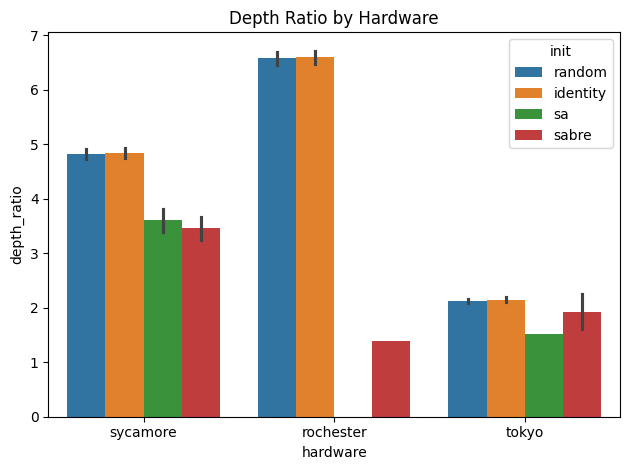

In [21]:
sns.barplot(x='hardware', y='depth_ratio', hue='init', data=df)
plt.title('Depth Ratio by Hardware')
plt.tight_layout()
plt.savefig('depth_ratio_by_hardware.png')

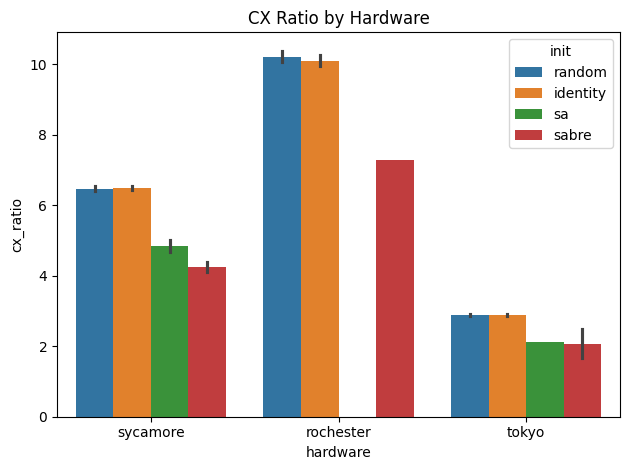

In [22]:
sns.barplot(x='hardware', y='cx_ratio', hue='init', data=df)
plt.title('CX Ratio by Hardware')
plt.tight_layout()
plt.savefig('cx_ratio_by_hardware.png')